# Parameter-Variational VINDy for Vehicle Dynamics

This notebook implements the VINDy workflow the project actually needs:

\[
\dot{x}_k = \Theta(x_k,u_k)\,\xi^{(r(k))} + \epsilon_k
\]

where each parameter realization / trajectory group has its own sparse coefficient vector \(\xi^{(r)}\). The final model is not one pooled coefficient vector. It is an empirical distribution:

\[
\xi \sim q(\xi)
\]

This is the uncertainty distribution that should be sampled inside SMPC.

Core idea:

1. Build a reduced physics-informed library.
2. Fit a sparse coefficient vector per parameter-realization group.
3. Estimate the coefficient distribution across groups.
4. Validate the mean model and uncertainty coverage.
5. Export \(q(\xi)\) for SMPC scenario rollout.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from scipy.stats import norm
except Exception:
    norm = None

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

rng = np.random.default_rng(42)
print("Imports loaded.")

Imports loaded.


## 1. Load data

Expected arrays:

\[
X=[v_x,v_y,\omega,\alpha_f,\alpha_r],\quad
U=[\delta,T_r],\quad
\dot X=[\dot v_x,\dot v_y,\dot\omega]
\]

For parameter-variational VINDy, the dataset should also contain a per-sample group identifier such as `train_param_id`, `train_traj_id`, or `train_run_id`.

In [2]:
# ============================================================
# LOAD DATA
# ============================================================

candidate_paths = [
    Path("Data/vindy_data_rich_excitation.npz"),
    Path("../Data/vindy_data_rich_excitation.npz"),
    Path("/mnt/data/Data/vindy_data_rich_excitation.npz"),
    Path("Data/vindy_data.npz"),
    Path("../Data/vindy_data.npz"),
    Path("/mnt/data/Data/vindy_data.npz"),
]

data_path = None
for p in candidate_paths:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError(
        "Could not find a VINDy data .npz file. Put vindy_data_rich_excitation.npz "
        "inside Data/ next to this notebook, or update candidate_paths."
    )

print("Loading:", data_path)
data = np.load(data_path, allow_pickle=True)
print("Available keys:")
print(sorted(data.files))

X_train  = data["X_train"]
Xd_train = data["Xd_train"]
U_train  = data["U_train"]

X_val  = data["X_val"]
Xd_val = data["Xd_val"]
U_val  = data["U_val"]

has_test = all(k in data.files for k in ["X_test", "Xd_test", "U_test"])
if has_test:
    X_test  = data["X_test"]
    Xd_test = data["Xd_test"]
    U_test  = data["U_test"]
else:
    X_test = Xd_test = U_test = None

print("\nShapes:")
print("  X_train :", X_train.shape, "Xd_train:", Xd_train.shape, "U_train:", U_train.shape)
print("  X_val   :", X_val.shape,   "Xd_val  :", Xd_val.shape,   "U_val  :", U_val.shape)
if has_test:
    print("  X_test  :", X_test.shape,  "Xd_test :", Xd_test.shape,  "U_test :", U_test.shape)

state_names = ["vx", "vy", "omega", "alpha_f", "alpha_r"]
input_names = ["delta", "Tr"]
target_names = ["vx_dot", "vy_dot", "omega_dot"]

print("\nTraining coverage:")
print(f"  alpha_f: [{X_train[:,3].min()*180/np.pi:+.2f}, {X_train[:,3].max()*180/np.pi:+.2f}] deg")
print(f"  alpha_r: [{X_train[:,4].min()*180/np.pi:+.2f}, {X_train[:,4].max()*180/np.pi:+.2f}] deg")
print(f"  vx     : [{X_train[:,0].min():+.2f}, {X_train[:,0].max():+.2f}] m/s")

Loading: Data\vindy_data_rich_excitation.npz
Available keys:
['U_test', 'U_train', 'U_val', 'X_test', 'X_train', 'X_val', 'Xd_test', 'Xd_train', 'Xd_val', 'nom_B_f', 'nom_B_r', 'nom_C_f', 'nom_C_r', 'nom_D_f', 'nom_D_r', 'nom_E_f', 'nom_E_r', 'nom_Jz', 'nom_M', 'nom_R_wheel', 'nom_lf', 'nom_lr', 'ptest_B_f', 'ptest_B_r', 'ptest_C_f', 'ptest_C_r', 'ptest_D_f', 'ptest_D_r', 'ptest_E_f', 'ptest_E_r', 'ptest_Jz', 'ptest_M', 'ptest_lf', 'ptest_lr', 'ptrain_B_f', 'ptrain_B_r', 'ptrain_C_f', 'ptrain_C_r', 'ptrain_D_f', 'ptrain_D_r', 'ptrain_E_f', 'ptrain_E_r', 'ptrain_Jz', 'ptrain_M', 'ptrain_lf', 'ptrain_lr', 'pval_B_f', 'pval_B_r', 'pval_C_f', 'pval_C_r', 'pval_D_f', 'pval_D_r', 'pval_E_f', 'pval_E_r', 'pval_Jz', 'pval_M', 'pval_lf', 'pval_lr', 'test_L_straight', 'test_R_turn', 'test_T_exc', 'test_delta_exc', 'test_laps', 'test_param_id', 'test_run_id', 'test_sim_duration', 'test_t', 'test_traj_id', 'test_v_base', 'test_v_ref', 'test_window_score', 'train_L_straight', 'train_R_turn', 'train

In [3]:
# ============================================================
# GROUP ID SELECTION
# ============================================================

def choose_group_id(data, split):
    """
    Prefer parameter ID because one coefficient vector should represent one
    parameter realization. Fall back to trajectory or run ID if necessary.
    """
    candidates = [
        f"{split}_param_id",
        f"{split}_traj_id",
        f"{split}_run_id",
        f"{split}_window_id",
        f"{split}_sample_traj_id",
        f"{split}_sample_run_id",
    ]
    for key in candidates:
        if key in data.files:
            return key, data[key]
    raise RuntimeError(
        f"No group ID found for split={split}. Regenerate the data and save per-sample "
        f"{split}_param_id or {split}_run_id. Parameter-variational VINDy needs group IDs."
    )

train_group_key, train_group_id = choose_group_id(data, "train")
val_group_key, val_group_id = choose_group_id(data, "val")

if has_test:
    test_group_key, test_group_id = choose_group_id(data, "test")
else:
    test_group_key, test_group_id = None, None

print("Group keys:")
print("  train:", train_group_key, "unique groups:", len(np.unique(train_group_id)))
print("  val  :", val_group_key,   "unique groups:", len(np.unique(val_group_id)))
if has_test:
    print("  test :", test_group_key,  "unique groups:", len(np.unique(test_group_id)))

assert len(train_group_id) == X_train.shape[0]
assert len(val_group_id) == X_val.shape[0]
if has_test:
    assert len(test_group_id) == X_test.shape[0]

Group keys:
  train: train_param_id unique groups: 120
  val  : val_param_id unique groups: 8
  test : test_param_id unique groups: 10


## 2. Build the reduced physics-informed library

The library is deliberately reduced to avoid high-order collinearity. The 7th and 9th powers are intentionally excluded.

In [4]:
# ============================================================
# REDUCED VEHICLE LIBRARY
# ============================================================

def build_vehicle_library(X, U):
    """
    X columns: [vx, vy, omega, alpha_f, alpha_r]
    U columns: [delta, Tr]
    """
    vx = X[:, 0]
    vy = X[:, 1]
    omega = X[:, 2]
    af = X[:, 3]
    ar = X[:, 4]

    delta = U[:, 0]
    Tr = U[:, 1]

    s = np.sin(delta)
    c = np.cos(delta)

    Theta = np.column_stack([
        omega * vy,          # 0
        omega * vx,          # 1
        vx,                  # 2
        vy,                  # 3
        Tr,                  # 4
        delta,               # 5
        af * s,              # 6
        af * c,              # 7
        af**3 * s,           # 8
        af**3 * c,           # 9
        af**5 * s,           # 10
        af**5 * c,           # 11
        ar,                  # 12
        ar**3,               # 13
        ar**5,               # 14
        vx * af * c,         # 15
        vx * ar,             # 16
    ])

    terms = [
        "omega*vy",
        "omega*vx",
        "vx",
        "vy",
        "Tr",
        "delta",
        "af*sin(d)",
        "af*cos(d)",
        "af^3*sin(d)",
        "af^3*cos(d)",
        "af^5*sin(d)",
        "af^5*cos(d)",
        "ar",
        "ar^3",
        "ar^5",
        "vx*af*cos(d)",
        "vx*ar",
    ]
    return Theta, terms

Theta_train, terms = build_vehicle_library(X_train, U_train)
Theta_val, _ = build_vehicle_library(X_val, U_val)
if has_test:
    Theta_test, _ = build_vehicle_library(X_test, U_test)
else:
    Theta_test = None

print("Theta_train shape:", Theta_train.shape)
print("Number of terms:", len(terms))
for i, t in enumerate(terms):
    print(f"[{i:2d}] {t}")

assert len(terms) == 17
assert all("af^7" not in t for t in terms)
assert all("af^9" not in t for t in terms)
assert all("ar^7" not in t for t in terms)
assert all("ar^9" not in t for t in terms)

print("\nClean reduced 17-term library is active.")

Theta_train shape: (352751, 17)
Number of terms: 17
[ 0] omega*vy
[ 1] omega*vx
[ 2] vx
[ 3] vy
[ 4] Tr
[ 5] delta
[ 6] af*sin(d)
[ 7] af*cos(d)
[ 8] af^3*sin(d)
[ 9] af^3*cos(d)
[10] af^5*sin(d)
[11] af^5*cos(d)
[12] ar
[13] ar^3
[14] ar^5
[15] vx*af*cos(d)
[16] vx*ar

Clean reduced 17-term library is active.


Condition number kappa(Theta) = 434.4
  OK: kappa < 1e3


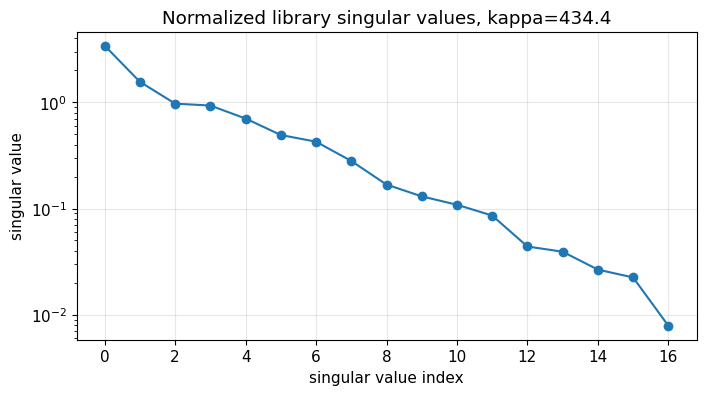

In [5]:
# ============================================================
# CONDITION NUMBER CHECK
# ============================================================

col_norms = np.linalg.norm(Theta_train, axis=0)
col_norms[col_norms == 0.0] = 1.0
Theta_n = Theta_train / col_norms
svals = np.linalg.svd(Theta_n, compute_uv=False)
kappa = svals[0] / svals[-1]

print(f"Condition number kappa(Theta) = {kappa:.1f}")
if kappa < 1e3:
    print("  OK: kappa < 1e3")
else:
    print("  WARNING: kappa > 1e3, strong collinearity remains")

plt.figure(figsize=(8, 4))
plt.semilogy(svals, marker="o")
plt.xlabel("singular value index")
plt.ylabel("singular value")
plt.title(f"Normalized library singular values, kappa={kappa:.1f}")
plt.grid(True, alpha=0.3)
plt.show()

## 3. Channel-specific physical active sets

This is not pruning after the fact. These are physically allowed terms per equation.

\[
\dot v_x \leftarrow \omega v_y, T_r, G_f(\alpha_f)\sin\delta
\]

\[
\dot v_y \leftarrow -\omega v_x, G_f(\alpha_f)\cos\delta, G_r(\alpha_r)
\]

\[
\dot \omega \leftarrow G_f(\alpha_f)\cos\delta, G_r(\alpha_r)
\]

In [6]:
# ============================================================
# PHYSICAL ACTIVE SETS
# ============================================================

channel_names = ["vx_dot", "vy_dot", "omega_dot"]
term_to_idx = {t: i for i, t in enumerate(terms)}

active_terms_by_channel = {
    "vx_dot": [
        "omega*vy",
        "Tr",
        "af*sin(d)",
        "af^3*sin(d)",
        "af^5*sin(d)",
    ],
    "vy_dot": [
        "omega*vx",
        "af*cos(d)",
        "af^3*cos(d)",
        "af^5*cos(d)",
        "ar",
        "ar^3",
        "ar^5",
    ],
    "omega_dot": [
        "af*cos(d)",
        "af^3*cos(d)",
        "af^5*cos(d)",
        "ar",
        "ar^3",
        "ar^5",
    ],
}

active_idx_by_channel = {
    ch: np.array([term_to_idx[t] for t in active_terms], dtype=int)
    for ch, active_terms in active_terms_by_channel.items()
}

for ch in channel_names:
    print(f"\n{ch} active terms:")
    for i in active_idx_by_channel[ch]:
        print(f"  [{i:2d}] {terms[i]}")


vx_dot active terms:
  [ 0] omega*vy
  [ 4] Tr
  [ 6] af*sin(d)
  [ 8] af^3*sin(d)
  [10] af^5*sin(d)

vy_dot active terms:
  [ 1] omega*vx
  [ 7] af*cos(d)
  [ 9] af^3*cos(d)
  [11] af^5*cos(d)
  [12] ar
  [13] ar^3
  [14] ar^5

omega_dot active terms:
  [ 7] af*cos(d)
  [ 9] af^3*cos(d)
  [11] af^5*cos(d)
  [12] ar
  [13] ar^3
  [14] ar^5


## 4. Priors for group-wise Bayesian VINDy

These priors regularize each parameter-realization fit. The coefficient distribution \(q(\xi)\) is then built from the posterior means across groups. This means the dominant uncertainty comes from parameter-to-parameter variation, not from one pooled posterior around an average model.

In [7]:
# ============================================================
# RAW COEFFICIENT PRIORS
# ============================================================

sigma_prior_raw = {
    # inertial coupling
    "omega*vy": 5.0,
    "omega*vx": 5.0,

    # direct standalone terms: intentionally discouraged if ever enabled
    "vx": 0.05,
    "vy": 0.05,
    "delta": 0.05,

    # torque coefficient true scale is roughly 1 / (M * R_wheel) ~= 0.0022
    "Tr": 0.01,

    # front tire projected through sin(delta), mostly affects vx_dot
    "af*sin(d)": 100.0,
    "af^3*sin(d)": 3000.0,
    "af^5*sin(d)": 50000.0,

    # front tire projected through cos(delta), affects vy_dot and omega_dot
    "af*cos(d)": 100.0,
    "af^3*cos(d)": 3000.0,
    "af^5*cos(d)": 50000.0,

    # rear tire
    "ar": 100.0,
    "ar^3": 3000.0,
    "ar^5": 50000.0,

    # compensation terms: intentionally discouraged if ever enabled
    "vx*af*cos(d)": 0.05,
    "vx*ar": 0.05,
}

print("Priors used by active channel terms:")
for ch in channel_names:
    print(f"\n{ch}:")
    for t in active_terms_by_channel[ch]:
        print(f"  {t:20s} sigma_prior={sigma_prior_raw[t]:.4g}")

Priors used by active channel terms:

vx_dot:
  omega*vy             sigma_prior=5
  Tr                   sigma_prior=0.01
  af*sin(d)            sigma_prior=100
  af^3*sin(d)          sigma_prior=3000
  af^5*sin(d)          sigma_prior=5e+04

vy_dot:
  omega*vx             sigma_prior=5
  af*cos(d)            sigma_prior=100
  af^3*cos(d)          sigma_prior=3000
  af^5*cos(d)          sigma_prior=5e+04
  ar                   sigma_prior=100
  ar^3                 sigma_prior=3000
  ar^5                 sigma_prior=5e+04

omega_dot:
  af*cos(d)            sigma_prior=100
  af^3*cos(d)          sigma_prior=3000
  af^5*cos(d)          sigma_prior=5e+04
  ar                   sigma_prior=100
  ar^3                 sigma_prior=3000
  ar^5                 sigma_prior=5e+04


## 4. Helper functions

In [8]:
# ============================================================
# METRICS AND FITTING HELPERS
# ============================================================

def regression_metrics(y_true, y_pred):
    err = y_true - y_pred
    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))
    bias = np.mean(err)
    nrmse = rmse / (np.std(y_true) + 1e-12)
    ss_res = np.sum(err**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2) + 1e-12
    r2 = 1.0 - ss_res / ss_tot
    return {"rmse": rmse, "mae": mae, "bias": bias, "nrmse": nrmse, "r2": r2}


def print_metric_table(name, Y_true, Y_pred):
    print("\n" + "="*78)
    print(name)
    print("="*78)
    for j, ch in enumerate(channel_names):
        m = regression_metrics(Y_true[:, j], Y_pred[:, j])
        status = "PASS" if m["r2"] > 0.90 else "FAIL"
        print(
            f"{ch:10s} | RMSE={m['rmse']:10.5f} | NRMSE={m['nrmse']:8.4f} | "
            f"Bias={m['bias']:+10.5f} | R2={m['r2']:9.6f} | {status}"
        )


def solve_ridge_active(Theta, y, active_idx, ridge=1e-8):
    Theta_c = Theta[:, active_idx]
    A = Theta_c.T @ Theta_c + ridge * np.eye(len(active_idx))
    b = Theta_c.T @ y
    beta_c = np.linalg.solve(A, b)
    beta_full = np.zeros(Theta.shape[1])
    beta_full[active_idx] = beta_c
    return beta_full


def solve_bayes_active(Theta, y, active_idx, sigma_prior_active, sigma_eps):
    Theta_c = Theta[:, active_idx]
    Lambda = np.diag(1.0 / (sigma_prior_active**2))
    A = (Theta_c.T @ Theta_c) / (sigma_eps**2) + Lambda
    b = (Theta_c.T @ y) / (sigma_eps**2)
    mu_c = np.linalg.solve(A, b)
    Sigma_c = np.linalg.inv(A)
    mu_full = np.zeros(Theta.shape[1])
    Sigma_full = np.zeros((Theta.shape[1], Theta.shape[1]))
    mu_full[active_idx] = mu_c
    Sigma_full[np.ix_(active_idx, active_idx)] = Sigma_c
    return mu_full, Sigma_full


def predict_from_coeffs(Theta, coeffs_by_channel):
    Y = np.zeros((Theta.shape[0], len(channel_names)))
    for j, ch in enumerate(channel_names):
        Y[:, j] = Theta @ coeffs_by_channel[ch]
    return Y

## 5. Baseline pooled deterministic model

This baseline is intentionally included to show the failure mode: one averaged coefficient vector for all parameter-realized trajectories.

In [9]:
# ============================================================
# POOLED PHYSICAL MODEL BASELINE
# ============================================================

pooled_coeffs = {}
for j, ch in enumerate(channel_names):
    active_idx = active_idx_by_channel[ch]
    pooled_coeffs[ch] = solve_ridge_active(
        Theta_train,
        Xd_train[:, j],
        active_idx=active_idx,
        ridge=1e-8,
    )

Xd_train_pred_pooled = predict_from_coeffs(Theta_train, pooled_coeffs)
Xd_val_pred_pooled = predict_from_coeffs(Theta_val, pooled_coeffs)

print_metric_table("POOLED BASELINE — TRAIN", Xd_train, Xd_train_pred_pooled)
print_metric_table("POOLED BASELINE — VAL", Xd_val, Xd_val_pred_pooled)
if has_test:
    Xd_test_pred_pooled = predict_from_coeffs(Theta_test, pooled_coeffs)
    print_metric_table("POOLED BASELINE — TEST", Xd_test, Xd_test_pred_pooled)


POOLED BASELINE — TRAIN
vx_dot     | RMSE=   0.11565 | NRMSE=  0.0886 | Bias=  -0.00167 | R2= 0.992143 | PASS
vy_dot     | RMSE=   0.39897 | NRMSE=  0.5769 | Bias=  +0.02333 | R2= 0.667137 | FAIL
omega_dot  | RMSE=   0.24384 | NRMSE=  0.6463 | Bias=  +0.00678 | R2= 0.582338 | FAIL

POOLED BASELINE — VAL
vx_dot     | RMSE=   0.11543 | NRMSE=  0.0884 | Bias=  +0.00488 | R2= 0.992181 | PASS
vy_dot     | RMSE=   0.41470 | NRMSE=  0.5710 | Bias=  -0.03594 | R2= 0.673962 | FAIL
omega_dot  | RMSE=   0.24452 | NRMSE=  0.6027 | Bias=  +0.02096 | R2= 0.636754 | FAIL

POOLED BASELINE — TEST
vx_dot     | RMSE=   0.10760 | NRMSE=  0.0805 | Bias=  -0.01137 | R2= 0.993515 | PASS
vy_dot     | RMSE=   0.40093 | NRMSE=  0.5482 | Bias=  -0.01536 | R2= 0.699471 | FAIL
omega_dot  | RMSE=   0.23616 | NRMSE=  0.6387 | Bias=  +0.05183 | R2= 0.592004 | FAIL


## 6. Fit coefficient vectors per parameter-realization group

This is the actual parameter-variational VINDy step:

\[
\xi^{(1)}, \xi^{(2)}, \ldots, \xi^{(N_g)}
\]

Each group corresponds preferably to one `param_id`. If `param_id` is unavailable, the notebook falls back to trajectory or run IDs.

In [10]:
# ============================================================
# GROUP-WISE BAYESIAN COEFFICIENT FITS
# ============================================================

def estimate_within_group_sigma(Theta, Xd, group_id, min_samples=80, ridge=1e-8):
    """
    Estimate channel noise/model residual scale from within-group fits.
    This avoids using the much larger pooled residual caused by parameter variation.
    """
    residuals = {ch: [] for ch in channel_names}

    for gid in np.unique(group_id):
        mask = group_id == gid
        if np.sum(mask) < min_samples:
            continue

        Theta_g = Theta[mask]
        Xd_g = Xd[mask]

        for j, ch in enumerate(channel_names):
            active_idx = active_idx_by_channel[ch]
            beta = solve_ridge_active(Theta_g, Xd_g[:, j], active_idx, ridge=ridge)
            residuals[ch].append(Xd_g[:, j] - Theta_g @ beta)

    sigma_eps = {}
    for ch in channel_names:
        rr = np.concatenate(residuals[ch])
        sigma_eps[ch] = float(np.std(rr, ddof=1))
    return sigma_eps


def fit_groupwise_coefficients(Theta, Xd, group_id, min_samples=80, ridge=1e-8, use_bayes=True, sigma_eps=None):
    unique_groups = np.unique(group_id)
    used_groups = []
    coeffs_by_channel = {ch: [] for ch in channel_names}
    covs_by_channel = {ch: [] for ch in channel_names}
    r2_by_channel = {ch: [] for ch in channel_names}
    residuals_by_channel = {ch: [] for ch in channel_names}
    samples_by_group = []

    for gid in unique_groups:
        mask = group_id == gid
        n = int(np.sum(mask))
        if n < min_samples:
            continue

        Theta_g = Theta[mask]
        Xd_g = Xd[mask]
        used_groups.append(gid)
        samples_by_group.append(n)

        for j, ch in enumerate(channel_names):
            active_idx = active_idx_by_channel[ch]

            if use_bayes:
                if sigma_eps is None:
                    raise ValueError("sigma_eps must be supplied when use_bayes=True")
                sigma_prior_active = np.array([sigma_prior_raw[terms[i]] for i in active_idx], dtype=float)
                beta, Sigma = solve_bayes_active(
                    Theta_g,
                    Xd_g[:, j],
                    active_idx,
                    sigma_prior_active=sigma_prior_active,
                    sigma_eps=sigma_eps[ch],
                )
            else:
                beta = solve_ridge_active(Theta_g, Xd_g[:, j], active_idx, ridge=ridge)
                Sigma = np.zeros((Theta.shape[1], Theta.shape[1]))

            y_pred = Theta_g @ beta
            m = regression_metrics(Xd_g[:, j], y_pred)

            coeffs_by_channel[ch].append(beta)
            covs_by_channel[ch].append(Sigma)
            r2_by_channel[ch].append(m["r2"])
            residuals_by_channel[ch].append(Xd_g[:, j] - y_pred)

    used_groups = np.array(used_groups)
    samples_by_group = np.array(samples_by_group)

    for ch in channel_names:
        coeffs_by_channel[ch] = np.vstack(coeffs_by_channel[ch])
        covs_by_channel[ch] = np.stack(covs_by_channel[ch], axis=0)
        r2_by_channel[ch] = np.array(r2_by_channel[ch])
        residuals_by_channel[ch] = np.concatenate(residuals_by_channel[ch])

    return used_groups, samples_by_group, coeffs_by_channel, covs_by_channel, r2_by_channel, residuals_by_channel

# Estimate within-group residual scale first, then do Bayesian group-wise fits.
sigma_eps_group = estimate_within_group_sigma(Theta_train, Xd_train, train_group_id, min_samples=80, ridge=1e-8)
print("Within-group sigma_eps used for group-wise Bayesian VINDy:")
for ch in channel_names:
    print(f"  {ch:10s}: {sigma_eps_group[ch]:.6f}")

train_used_groups, train_group_sizes, xi_train_groups, Sigma_train_groups, r2_train_groups, resid_train_groups = fit_groupwise_coefficients(
    Theta_train,
    Xd_train,
    train_group_id,
    min_samples=80,
    ridge=1e-8,
    use_bayes=True,
    sigma_eps=sigma_eps_group,
)

print("\nUsed training groups:", len(train_used_groups))
print("Group-size range:", train_group_sizes.min(), "to", train_group_sizes.max())

print("\nGroup-wise ORACLE fit quality on TRAIN groups:")
for ch in channel_names:
    vals = r2_train_groups[ch]
    print(
        f"{ch:10s} | median R2={np.median(vals):.4f} | mean R2={np.mean(vals):.4f} | "
        f"10th perc={np.percentile(vals, 10):.4f} | min={np.min(vals):.4f}"
    )

Within-group sigma_eps used for group-wise Bayesian VINDy:
  vx_dot    : 0.003536
  vy_dot    : 0.027978
  omega_dot : 0.022253

Used training groups: 120
Group-size range: 1903 to 3204

Group-wise ORACLE fit quality on TRAIN groups:
vx_dot     | median R2=1.0000 | mean R2=1.0000 | 10th perc=1.0000 | min=1.0000
vy_dot     | median R2=0.9994 | mean R2=0.9992 | 10th perc=0.9984 | min=0.9965
omega_dot  | median R2=0.9987 | mean R2=0.9984 | 10th perc=0.9971 | min=0.9940


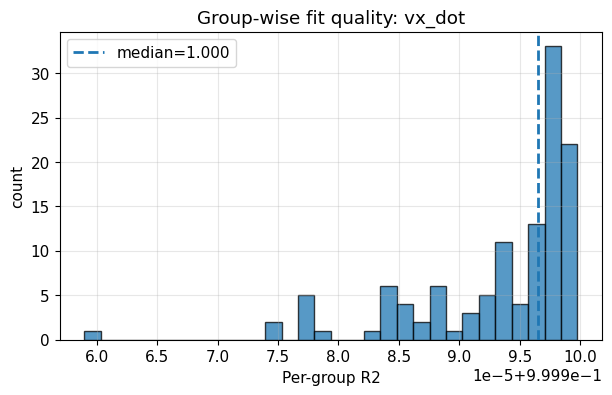

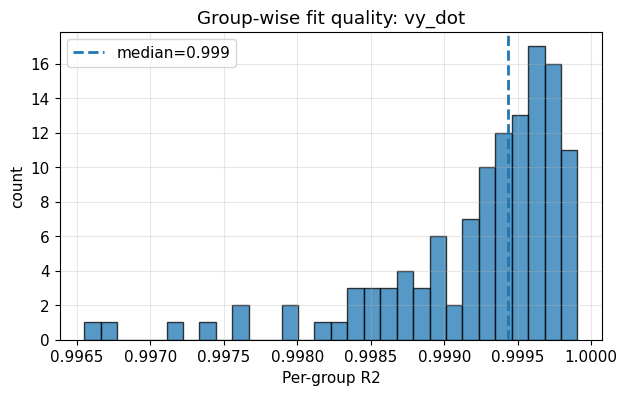

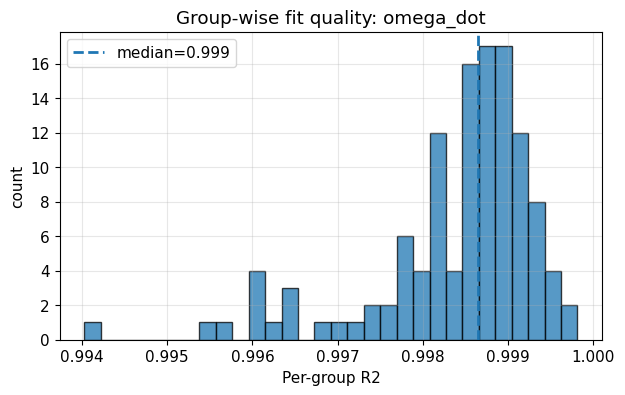

In [11]:
# Visualize group-wise R2 distributions
for ch in channel_names:
    vals = r2_train_groups[ch]
    plt.figure(figsize=(7, 4))
    plt.hist(vals, bins=30, edgecolor="k", alpha=0.75)
    plt.axvline(np.median(vals), linestyle="--", linewidth=2, label=f"median={np.median(vals):.3f}")
    plt.xlabel("Per-group R2")
    plt.ylabel("count")
    plt.title(f"Group-wise fit quality: {ch}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 7. Estimate the coefficient distribution \(q(\xi)\)

The empirical distribution of group-wise coefficients represents parameter-induced dynamics uncertainty.

In [12]:
# ============================================================
# EMPIRICAL COEFFICIENT DISTRIBUTION q(xi)
# ============================================================

def make_pd_cov(C, shrink=0.05, jitter=1e-10):
    """Shrink covariance toward diagonal and add jitter for stable sampling."""
    C = np.asarray(C, dtype=float)
    D = np.diag(np.diag(C))
    C_shrunk = (1.0 - shrink) * C + shrink * D
    C_shrunk = 0.5 * (C_shrunk + C_shrunk.T)
    C_shrunk += jitter * np.eye(C_shrunk.shape[0])
    return C_shrunk

q_mean = {}
q_cov = {}
q_std = {}

for ch in channel_names:
    active_idx = active_idx_by_channel[ch]
    B = xi_train_groups[ch][:, active_idx]
    mu = np.mean(B, axis=0)
    C = np.cov(B.T) if B.shape[0] > 1 else np.eye(B.shape[1]) * 1e-8
    C = make_pd_cov(C, shrink=0.05, jitter=1e-10)

    q_mean[ch] = mu
    q_cov[ch] = C
    q_std[ch] = np.sqrt(np.diag(C))

    print("\n" + "="*70)
    print(f"q(xi) for {ch}")
    print("="*70)
    for local_j, full_j in enumerate(active_idx):
        print(
            f"{terms[full_j]:20s} mean={mu[local_j]:+12.6f} "
            f"std={q_std[ch][local_j]:10.6f}"
        )


q(xi) for vx_dot
omega*vy             mean=   +1.005829 std=  0.012240
Tr                   mean=   +0.002197 std=  0.000192
af*sin(d)            mean=  -43.548396 std=  6.445888
af^3*sin(d)          mean= +423.228516 std= 87.392683
af^5*sin(d)          mean=-1480.061798 std=1233.480657

q(xi) for vy_dot
omega*vx             mean=   -0.996637 std=  0.002126
af*cos(d)            mean=  +43.066818 std=  6.393069
af^3*cos(d)          mean= -407.366786 std= 85.774881
af^5*cos(d)          mean=+1414.062787 std=1139.783489
ar                   mean=  +40.969143 std=  5.581072
ar^3                 mean=+1841.681438 std=887.054167
ar^5                 mean=-384495.578947 std=263231.368268

q(xi) for omega_dot
af*cos(d)            mean=  +40.222708 std=  6.216132
af^3*cos(d)          mean= -379.009209 std= 82.754116
af^5*cos(d)          mean=+1307.203164 std=1028.819673
ar                   mean=  -75.753890 std= 10.537229
ar^3                 mean=+1822.767870 std=819.543045
ar^5             

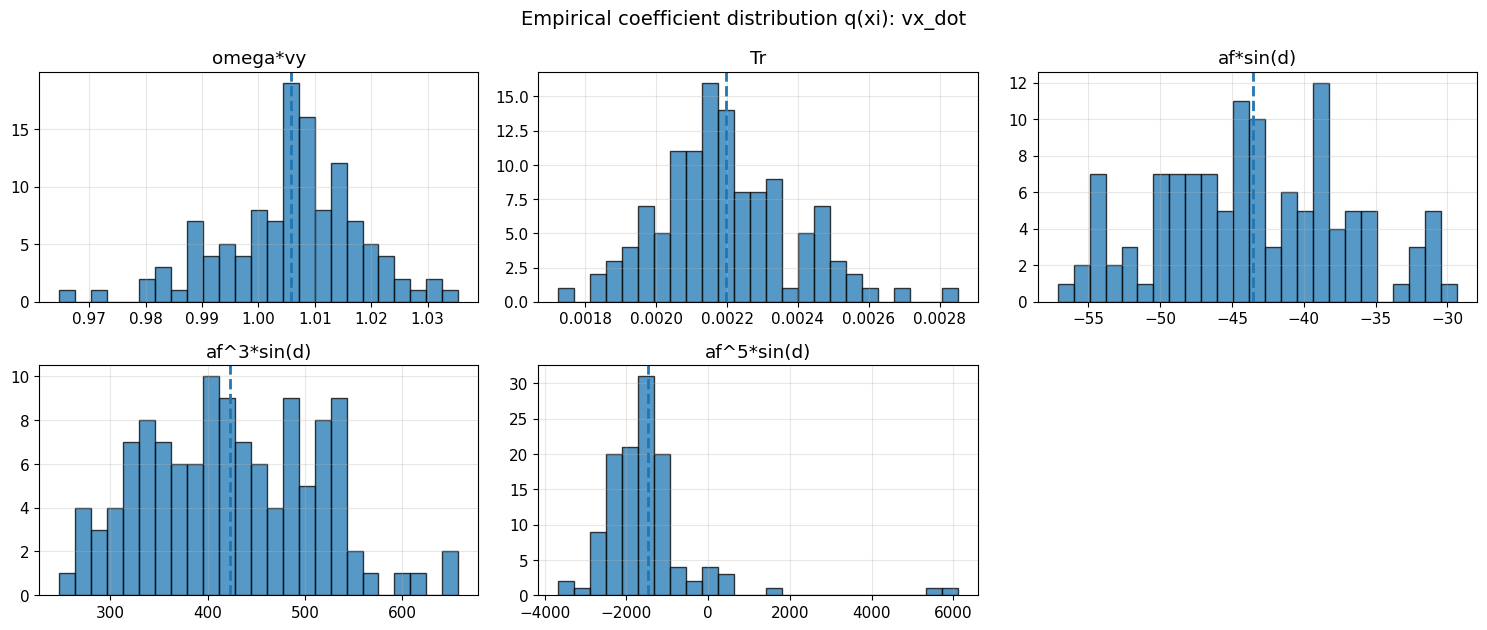

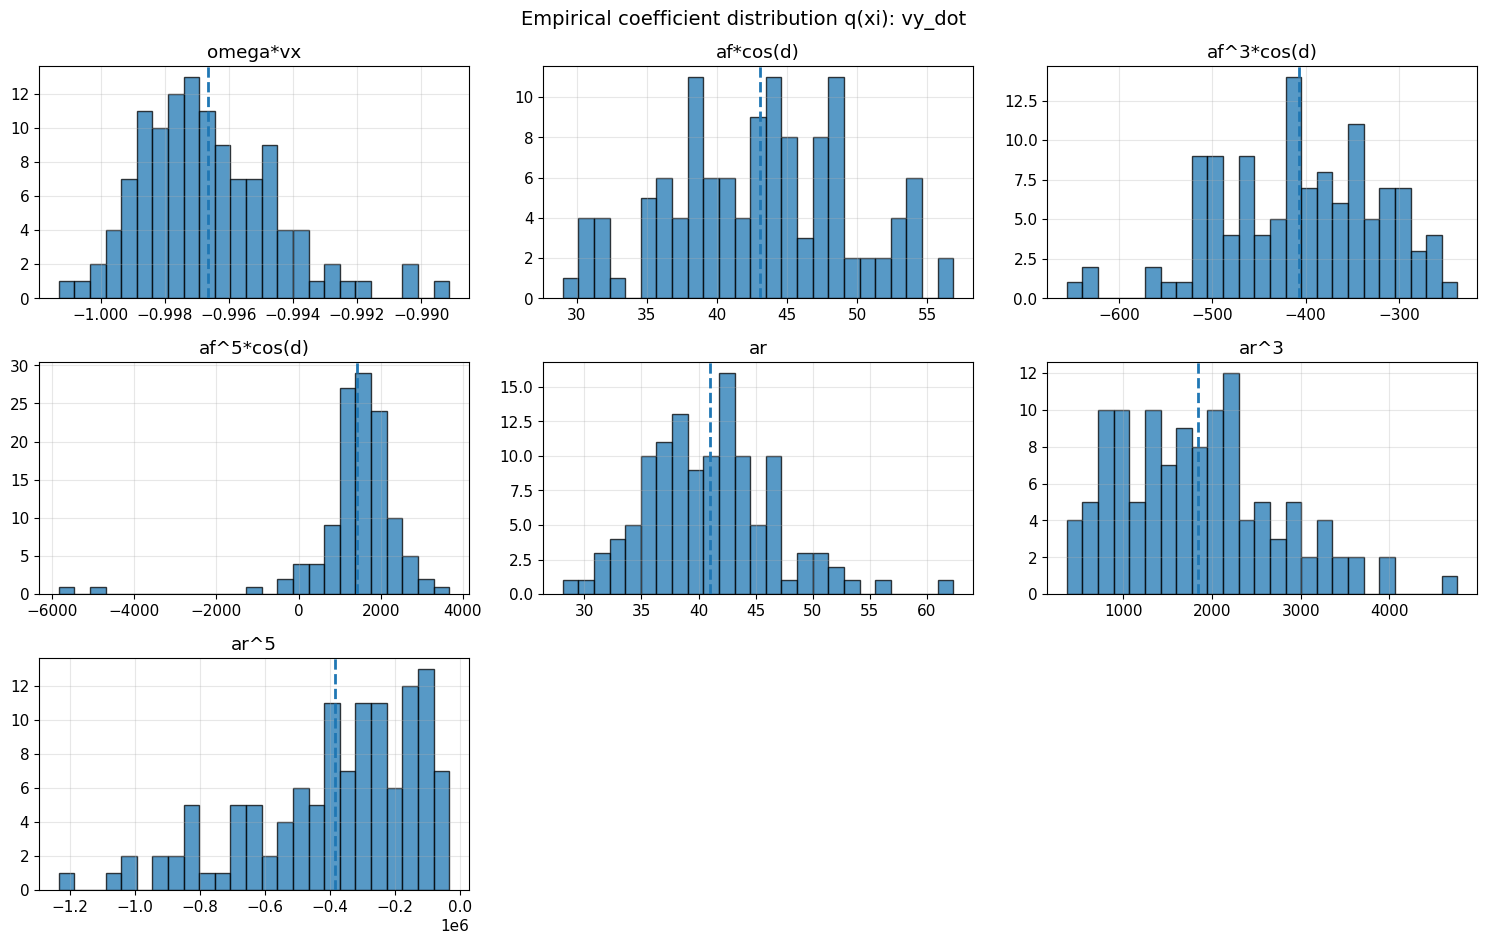

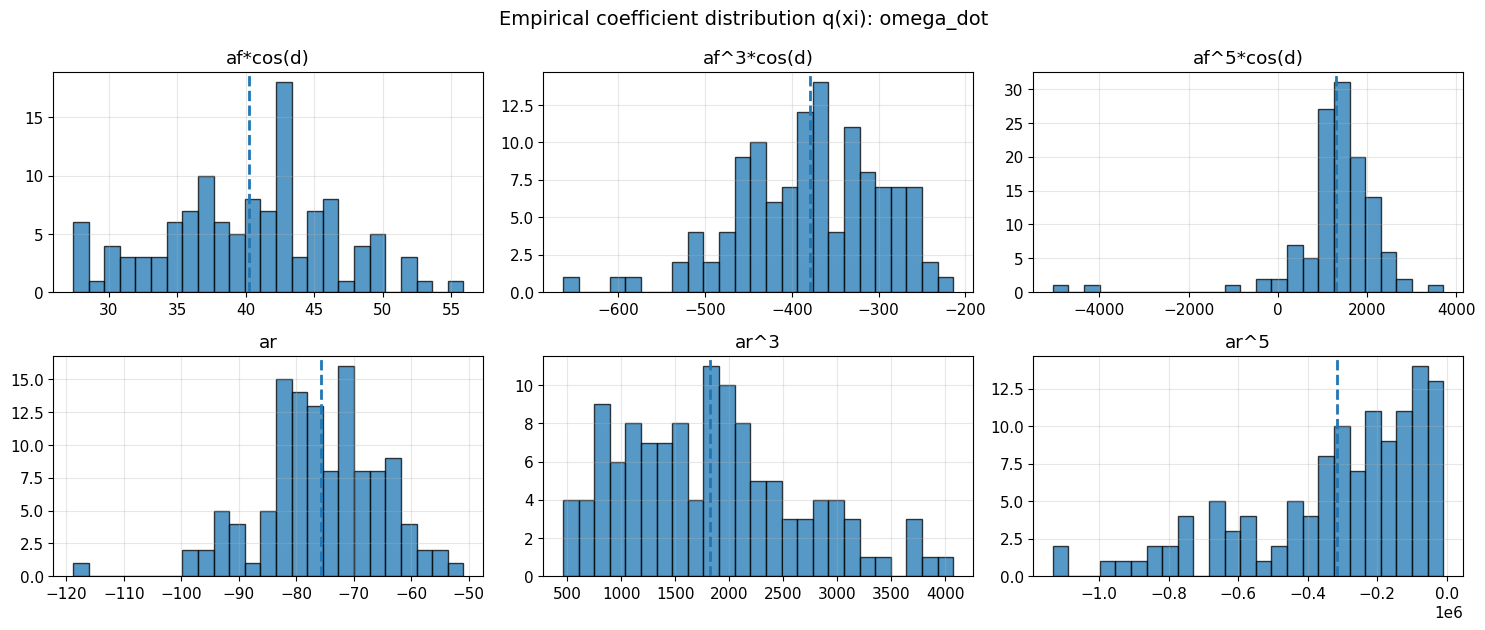

In [13]:
# Plot coefficient distributions for active terms
for ch in channel_names:
    active_idx = active_idx_by_channel[ch]
    B = xi_train_groups[ch][:, active_idx]

    n_terms = len(active_idx)
    n_cols = 3
    n_rows = int(np.ceil(n_terms / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.2*n_rows))
    axes = np.array(axes).reshape(-1)
    fig.suptitle(f"Empirical coefficient distribution q(xi): {ch}", fontsize=14)

    for ax, local_j, full_j in zip(axes, range(n_terms), active_idx):
        vals = B[:, local_j]
        ax.hist(vals, bins=25, edgecolor="k", alpha=0.75)
        ax.axvline(np.mean(vals), linestyle="--", linewidth=2)
        ax.set_title(terms[full_j])
        ax.grid(True, alpha=0.3)

    for ax in axes[n_terms:]:
        ax.axis("off")

    fig.tight_layout()
    plt.show()

## 8. Scenario prediction from \(q(\xi)\)

This is the object SMPC will use. Each scenario samples a coefficient vector from \(q(\xi)\).

In [14]:
# ============================================================
# SCENARIO SAMPLING AND PREDICTIVE DISTRIBUTION
# ============================================================

def sample_coefficients_from_q(n_scenarios=200, seed=123):
    rng_local = np.random.default_rng(seed)
    samples = {}
    for ch in channel_names:
        active_idx = active_idx_by_channel[ch]
        B_s = rng_local.multivariate_normal(q_mean[ch], q_cov[ch], size=n_scenarios)
        full = np.zeros((n_scenarios, len(terms)))
        full[:, active_idx] = B_s
        samples[ch] = full
    return samples


def predictive_distribution(Theta, n_scenarios=200, seed=123):
    xi_samples = sample_coefficients_from_q(n_scenarios=n_scenarios, seed=seed)
    n = Theta.shape[0]
    Y_s = np.zeros((n_scenarios, n, len(channel_names)))
    for j, ch in enumerate(channel_names):
        Y_s[:, :, j] = xi_samples[ch] @ Theta.T
    Y_mean = np.mean(Y_s, axis=0)
    Y_std = np.std(Y_s, axis=0, ddof=1)
    return Y_mean, Y_std, Y_s


def coverage_table(Y_true, Y_mean, Y_std, split_name):
    levels = [0.50, 0.75, 0.90, 0.95, 0.99]
    if norm is not None:
        zvals = {level: norm.ppf(0.5 + level/2.0) for level in levels}
    else:
        zvals = {0.50: 0.6745, 0.75: 1.1503, 0.90: 1.6449, 0.95: 1.9600, 0.99: 2.5758}

    print("\n" + "="*78)
    print(f"Predictive coverage from q(xi): {split_name}")
    print("="*78)
    for j, ch in enumerate(channel_names):
        err_abs = np.abs(Y_true[:, j] - Y_mean[:, j])
        sig = Y_std[:, j] + 1e-12
        print(f"\n{ch}:")
        for level in levels:
            actual = np.mean(err_abs <= zvals[level] * sig)
            print(f"  nominal {int(level*100):2d}% -> actual {actual*100:6.2f}%")

# Scenario predictions
n_scenarios = 300
Y_train_mean, Y_train_std, _ = predictive_distribution(Theta_train, n_scenarios=n_scenarios, seed=1)
Y_val_mean, Y_val_std, _ = predictive_distribution(Theta_val, n_scenarios=n_scenarios, seed=2)

print_metric_table("q(xi) MEAN MODEL — TRAIN", Xd_train, Y_train_mean)
print_metric_table("q(xi) MEAN MODEL — VAL", Xd_val, Y_val_mean)
coverage_table(Xd_val, Y_val_mean, Y_val_std, "VAL")

if has_test:
    Y_test_mean, Y_test_std, _ = predictive_distribution(Theta_test, n_scenarios=n_scenarios, seed=3)
    print_metric_table("q(xi) MEAN MODEL — TEST", Xd_test, Y_test_mean)
    coverage_table(Xd_test, Y_test_mean, Y_test_std, "TEST")


q(xi) MEAN MODEL — TRAIN
vx_dot     | RMSE=   0.11849 | NRMSE=  0.0908 | Bias=  -0.00283 | R2= 0.991751 | PASS
vy_dot     | RMSE=   0.56855 | NRMSE=  0.8222 | Bias=  +0.04800 | R2= 0.324036 | FAIL
omega_dot  | RMSE=   0.61476 | NRMSE=  1.6293 | Bias=  +0.05845 | R2=-1.654748 | FAIL

q(xi) MEAN MODEL — VAL
vx_dot     | RMSE=   0.11353 | NRMSE=  0.0870 | Bias=  +0.00513 | R2= 0.992437 | PASS
vy_dot     | RMSE=   0.62837 | NRMSE=  0.8652 | Bias=  -0.06885 | R2= 0.251422 | FAIL
omega_dot  | RMSE=   0.51645 | NRMSE=  1.2729 | Bias=  +0.08841 | R2=-0.620378 | FAIL

Predictive coverage from q(xi): VAL

vx_dot:
  nominal 50% -> actual  59.97%
  nominal 75% -> actual  81.84%
  nominal 90% -> actual  95.15%
  nominal 95% -> actual  99.04%
  nominal 99% -> actual 100.00%

vy_dot:
  nominal 50% -> actual  38.96%
  nominal 75% -> actual  65.08%
  nominal 90% -> actual  82.30%
  nominal 95% -> actual  97.51%
  nominal 99% -> actual 100.00%

omega_dot:
  nominal 50% -> actual  56.62%
  nominal 75% -

## 9. Validation/test group-wise oracle diagnostic

This is not the deployed controller. It checks whether the reduced physical library can fit unseen parameter groups if each group is allowed its own coefficients. If this is good but the mean model is weaker, the issue is correctly identified as parameter variation rather than a broken library.

In [15]:
# ============================================================
# ORACLE DIAGNOSTIC ON VALIDATION AND TEST GROUPS
# ============================================================

def oracle_group_report(split_name, Theta, Xd, group_id):
    # For diagnostics on held-out splits, estimate that split's within-group residual scale,
    # then fit group-wise Bayesian coefficients. This is an oracle check of library adequacy,
    # not the controller deployment mode.
    sigma_eps_split = estimate_within_group_sigma(Theta, Xd, group_id, min_samples=50, ridge=1e-8)
    used, sizes, coeffs, covs, r2s, resids = fit_groupwise_coefficients(
        Theta, Xd, group_id, min_samples=50, ridge=1e-8, use_bayes=True, sigma_eps=sigma_eps_split
    )
    print("\n" + "="*78)
    print(f"GROUP-WISE ORACLE DIAGNOSTIC — {split_name}")
    print("="*78)
    print("Used groups:", len(used), "group-size range:", sizes.min(), "to", sizes.max())
    for ch in channel_names:
        vals = r2s[ch]
        print(
            f"{ch:10s} | median R2={np.median(vals):.4f} | mean R2={np.mean(vals):.4f} | "
            f"10th perc={np.percentile(vals, 10):.4f} | min={np.min(vals):.4f}"
        )
    return used, sizes, coeffs, covs, r2s, resids

val_oracle = oracle_group_report("VAL", Theta_val, Xd_val, val_group_id)
if has_test:
    test_oracle = oracle_group_report("TEST", Theta_test, Xd_test, test_group_id)


GROUP-WISE ORACLE DIAGNOSTIC — VAL
Used groups: 8 group-size range: 1602 to 1602
vx_dot     | median R2=1.0000 | mean R2=1.0000 | 10th perc=1.0000 | min=1.0000
vy_dot     | median R2=0.9998 | mean R2=0.9997 | 10th perc=0.9994 | min=0.9992
omega_dot  | median R2=0.9994 | mean R2=0.9993 | 10th perc=0.9987 | min=0.9987

GROUP-WISE ORACLE DIAGNOSTIC — TEST
Used groups: 10 group-size range: 874 to 1800
vx_dot     | median R2=1.0000 | mean R2=1.0000 | 10th perc=1.0000 | min=1.0000
vy_dot     | median R2=0.9994 | mean R2=0.9994 | 10th perc=0.9991 | min=0.9989
omega_dot  | median R2=0.9985 | mean R2=0.9980 | 10th perc=0.9965 | min=0.9964


## 10. Tire curve diagnostics

The front and rear tire curves are reconstructed from the coefficient distributions. These are normalized as force over mass when using the lateral acceleration equation.

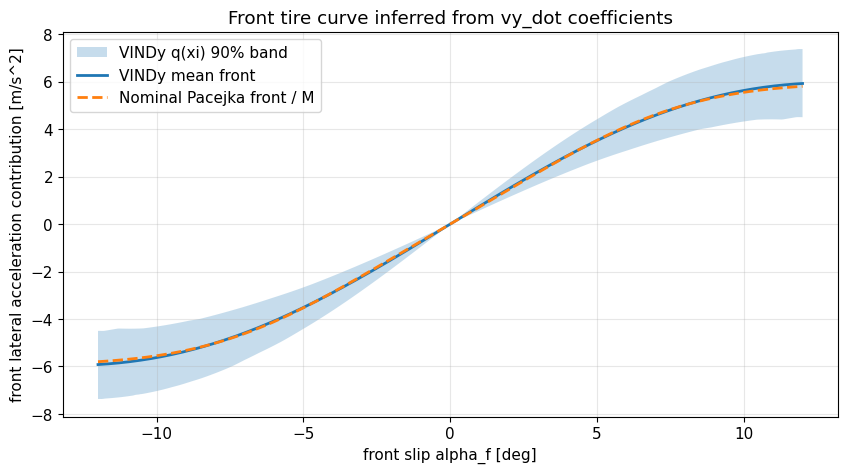

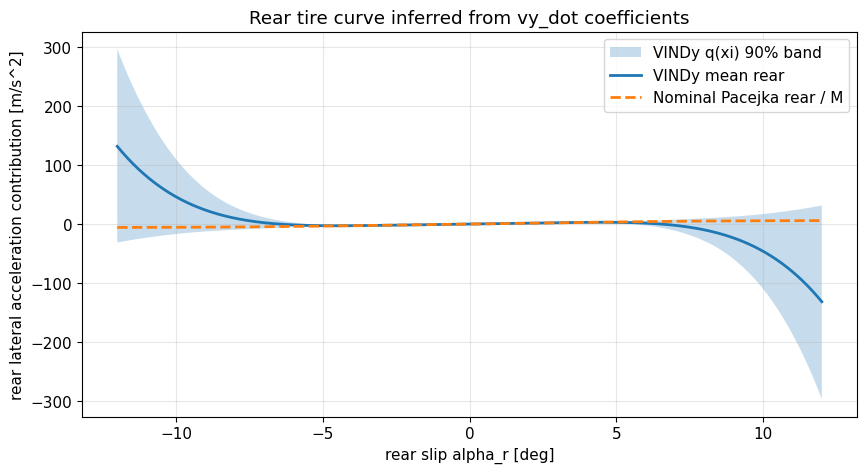

In [16]:
# ============================================================
# TIRE CURVE DIAGNOSTICS FROM COEFFICIENT DISTRIBUTION
# ============================================================

def pacejka(alpha, B, C, D, E):
    Ba = B * alpha
    return D * np.sin(C * np.arctan(Ba - E * (Ba - np.arctan(Ba))))


def get_nominal_or_default(key, default):
    data_key = f"nom_{key}"
    if data_key in data.files:
        return float(np.asarray(data[data_key]))
    return float(default)

nom = {
    "M": get_nominal_or_default("M", 1412.0),
    "Jz": get_nominal_or_default("Jz", 1536.7),
    "lf": get_nominal_or_default("lf", 1.015),
    "lr": get_nominal_or_default("lr", 1.895),
    "B_f": get_nominal_or_default("B_f", 0.0885 * (180.0 / np.pi)),
    "C_f": get_nominal_or_default("C_f", 1.4),
    "D_f": get_nominal_or_default("D_f", 8311.0),
    "E_f": get_nominal_or_default("E_f", -2.0),
    "B_r": get_nominal_or_default("B_r", 0.0885 * (180.0 / np.pi)),
    "C_r": get_nominal_or_default("C_r", 1.4),
    "D_r": get_nominal_or_default("D_r", 8311.0),
    "E_r": get_nominal_or_default("E_r", -2.0),
}

alpha_deg = np.linspace(-12, 12, 400)
alpha = np.deg2rad(alpha_deg)

# Sample coefficients
xi_s = sample_coefficients_from_q(n_scenarios=300, seed=99)

# Build front/rear acceleration curves from vy_dot channel
idx_af1 = term_to_idx["af*cos(d)"]
idx_af3 = term_to_idx["af^3*cos(d)"]
idx_af5 = term_to_idx["af^5*cos(d)"]
idx_ar1 = term_to_idx["ar"]
idx_ar3 = term_to_idx["ar^3"]
idx_ar5 = term_to_idx["ar^5"]

B_vy = xi_s["vy_dot"]
front_acc_samples = (
    B_vy[:, idx_af1, None] * alpha[None, :]
    + B_vy[:, idx_af3, None] * alpha[None, :]**3
    + B_vy[:, idx_af5, None] * alpha[None, :]**5
)
rear_acc_samples = (
    B_vy[:, idx_ar1, None] * alpha[None, :]
    + B_vy[:, idx_ar3, None] * alpha[None, :]**3
    + B_vy[:, idx_ar5, None] * alpha[None, :]**5
)

front_mean = front_acc_samples.mean(axis=0)
front_lo, front_hi = np.percentile(front_acc_samples, [5, 95], axis=0)
rear_mean = rear_acc_samples.mean(axis=0)
rear_lo, rear_hi = np.percentile(rear_acc_samples, [5, 95], axis=0)

# True nominal force-over-mass curves for reference
Ff_nom_over_M = pacejka(alpha, nom["B_f"], nom["C_f"], nom["D_f"], nom["E_f"]) / nom["M"]
Fr_nom_over_M = pacejka(alpha, nom["B_r"], nom["C_r"], nom["D_r"], nom["E_r"]) / nom["M"]

plt.figure(figsize=(10, 5))
plt.fill_between(alpha_deg, front_lo, front_hi, alpha=0.25, label="VINDy q(xi) 90% band")
plt.plot(alpha_deg, front_mean, linewidth=2, label="VINDy mean front")
plt.plot(alpha_deg, Ff_nom_over_M, "--", linewidth=2, label="Nominal Pacejka front / M")
plt.xlabel("front slip alpha_f [deg]")
plt.ylabel("front lateral acceleration contribution [m/s^2]")
plt.title("Front tire curve inferred from vy_dot coefficients")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.fill_between(alpha_deg, rear_lo, rear_hi, alpha=0.25, label="VINDy q(xi) 90% band")
plt.plot(alpha_deg, rear_mean, linewidth=2, label="VINDy mean rear")
plt.plot(alpha_deg, Fr_nom_over_M, "--", linewidth=2, label="Nominal Pacejka rear / M")
plt.xlabel("rear slip alpha_r [deg]")
plt.ylabel("rear lateral acceleration contribution [m/s^2]")
plt.title("Rear tire curve inferred from vy_dot coefficients")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 11. Time-series diagnostic on one validation group

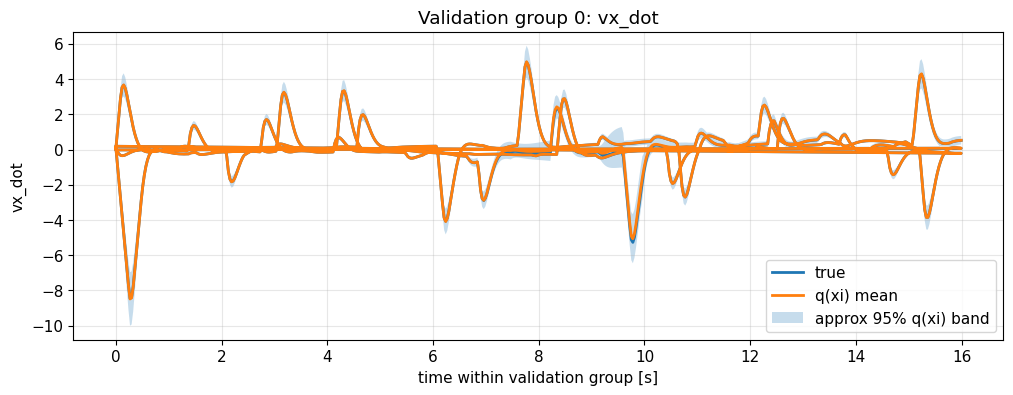

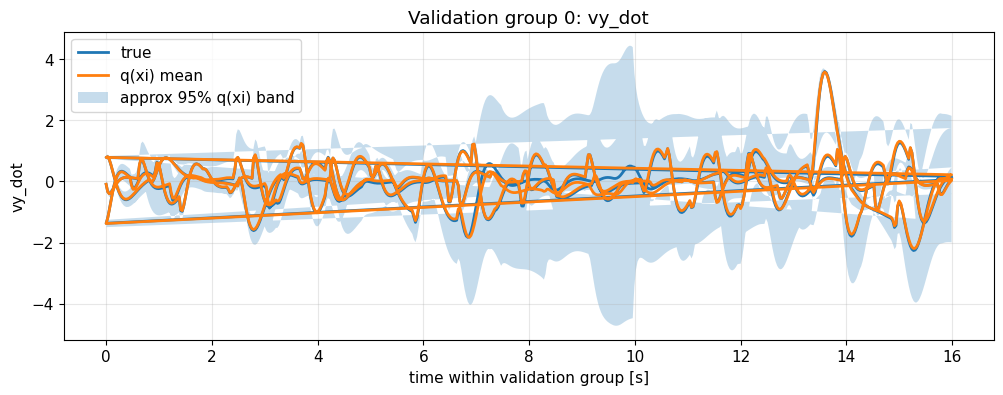

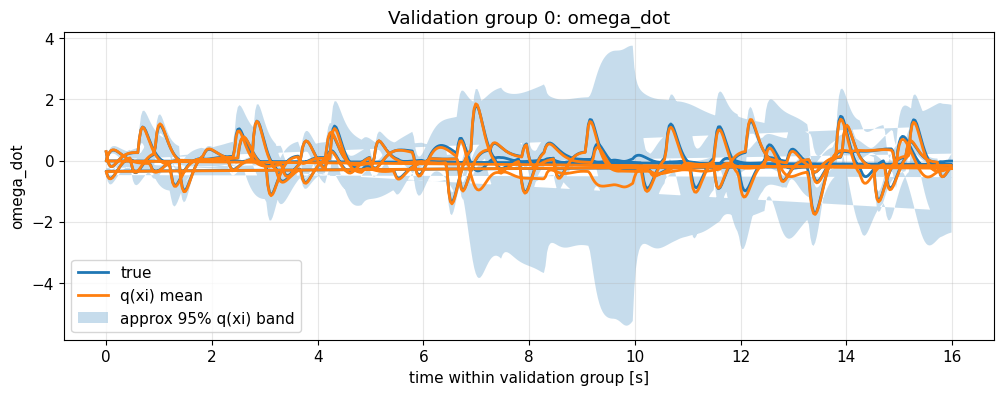

In [17]:
# ============================================================
# ONE VALIDATION GROUP TIME-SERIES DIAGNOSTIC
# ============================================================

# Choose a validation group with many samples
unique_val, counts_val = np.unique(val_group_id, return_counts=True)
chosen_gid = unique_val[np.argmax(counts_val)]
mask = val_group_id == chosen_gid

Theta_g = Theta_val[mask]
Y_true_g = Xd_val[mask]
Y_mean_g, Y_std_g, _ = predictive_distribution(Theta_g, n_scenarios=300, seed=55)

t_axis = np.arange(np.sum(mask))
if "val_t" in data.files:
    t_axis = data["val_t"][mask]
    t_axis = t_axis - t_axis[0]

for j, ch in enumerate(channel_names):
    plt.figure(figsize=(12, 4))
    plt.plot(t_axis, Y_true_g[:, j], label="true", linewidth=2)
    plt.plot(t_axis, Y_mean_g[:, j], label="q(xi) mean", linewidth=2)
    plt.fill_between(
        t_axis,
        Y_mean_g[:, j] - 1.96 * Y_std_g[:, j],
        Y_mean_g[:, j] + 1.96 * Y_std_g[:, j],
        alpha=0.25,
        label="approx 95% q(xi) band",
    )
    plt.xlabel("time within validation group [s]" if "val_t" in data.files else "sample index")
    plt.ylabel(ch)
    plt.title(f"Validation group {chosen_gid}: {ch}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

## 12. Export model for SMPC

The exported file contains the empirical coefficient distribution \(q(\xi)\). During SMPC, sample coefficient vectors from this distribution and roll out each scenario.

In [18]:
# ============================================================
# EXPORT q(xi) MODEL
# ============================================================

out_path = Path("vindy_parameter_variational_model.npz")

save_dict = {
    "terms": np.array(terms),
    "channel_names": np.array(channel_names),
    "source_data_path": np.array(str(data_path)),
    "train_group_key": np.array(train_group_key),
}

for ch in channel_names:
    key = ch.replace("_dot", "")  # vx, vy, omega
    active_idx = active_idx_by_channel[ch]
    save_dict[f"active_idx_{key}"] = active_idx
    save_dict[f"q_mean_{key}"] = q_mean[ch]
    save_dict[f"q_cov_{key}"] = q_cov[ch]
    save_dict[f"xi_groups_{key}"] = xi_train_groups[ch][:, active_idx]
    save_dict[f"q_std_{key}"] = q_std[ch]

np.savez(out_path, **save_dict)
print("Saved:", out_path.resolve())

print("\nSMPC usage sketch:")
print("  1. load vindy_parameter_variational_model.npz")
print("  2. sample xi_vx, xi_vy, xi_omega from q_mean/q_cov")
print("  3. at each MPC prediction step, build Theta(x,u)")
print("  4. roll out x_{k+1}^{(s)} = x_k^{(s)} + dt * Theta(x,u) @ xi^{(s)}")

Saved: C:\VS\vindy_parameter_variational_model.npz

SMPC usage sketch:
  1. load vindy_parameter_variational_model.npz
  2. sample xi_vx, xi_vy, xi_omega from q_mean/q_cov
  3. at each MPC prediction step, build Theta(x,u)
  4. roll out x_{k+1}^{(s)} = x_k^{(s)} + dt * Theta(x,u) @ xi^{(s)}


## 13. Minimal SMPC rollout function skeleton

This cell is intentionally a skeleton. It shows how to use the exported VINDy uncertainty inside a controller.

In [19]:
# ============================================================
# MINIMAL PREDICTION SKELETON FOR SMPC
# ============================================================

def compute_slip_angles(vx, vy, omega, delta, lf=1.015, lr=1.895):
    """Same slip convention as the generator."""
    vy_front = vy + omega * lf
    v_lat_w = vy_front * np.cos(delta) - vx * np.sin(delta)
    v_lon_w = vx * np.cos(delta) + vy_front * np.sin(delta)
    alpha_f = -np.arctan2(v_lat_w, max(abs(v_lon_w), 0.5))
    alpha_r = -np.arctan2(vy - omega * lr, max(abs(vx), 0.5))
    return alpha_f, alpha_r


def theta_row_from_state_input(x, u, lf=1.015, lr=1.895):
    """
    x = [vx, vy, omega]
    u = [delta, Tr]
    returns one 17-column library row.
    """
    vx, vy, omega = x
    delta, Tr = u
    af, ar = compute_slip_angles(vx, vy, omega, delta, lf=lf, lr=lr)
    s = np.sin(delta)
    c = np.cos(delta)
    return np.array([
        omega * vy,
        omega * vx,
        vx,
        vy,
        Tr,
        delta,
        af * s,
        af * c,
        af**3 * s,
        af**3 * c,
        af**5 * s,
        af**5 * c,
        ar,
        ar**3,
        ar**5,
        vx * af * c,
        vx * ar,
    ])


def sample_one_vindy_model(seed=None):
    rng_local = np.random.default_rng(seed)
    xi = {}
    for ch in channel_names:
        active_idx = active_idx_by_channel[ch]
        sample_active = rng_local.multivariate_normal(q_mean[ch], q_cov[ch])
        full = np.zeros(len(terms))
        full[active_idx] = sample_active
        xi[ch] = full
    return xi


def vindy_rhs(x, u, xi_model, lf=1.015, lr=1.895):
    th = theta_row_from_state_input(x, u, lf=lf, lr=lr)
    return np.array([
        th @ xi_model["vx_dot"],
        th @ xi_model["vy_dot"],
        th @ xi_model["omega_dot"],
    ])

# Example one-step prediction
x0 = np.array([20.0, 0.0, 0.0])
u0 = np.array([2.0*np.pi/180.0, 500.0])
xi_model = sample_one_vindy_model(seed=7)
dx0 = vindy_rhs(x0, u0, xi_model)
print("Example sampled dx =", dx0)

Example sampled dx = [1.01137962 1.61404136 1.60806398]
